# Environment

In [1]:
# base
import os
import gc
import pickle
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# # R
# import rpy2.robjects as ro
# from rpy2.robjects.conversion import localconverter
# %load_ext rpy2.ipython

# analysis & device specific
converter = get_converter()
CORES = 20
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

%matplotlib inline
mpl.rcdefaults()
gc.collect()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: bac

96

# Load Data

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "spatial" / "external" / "adata.h5ad")
adata.obs = adata.obs.drop(columns="ident")
sc.pp.filter_genes(adata, min_cells=10)
adata.layers["counts"] = adata.X.copy()
sc.pp.log1p(adata, layer="logcounts")
adata

In [ ]:
from pandas.api.types import CategoricalDtype

# fix spatial
adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm["SPATIAL"], 2)
adata.obs = adata.obs.rename(columns={"orig.ident" : "batch"})

slide_batch = "batch"

samples = adata.obs[slide_batch].unique()
ref = samples[0]
for n in np.arange(1, len(samples)):
    ref = samples[n - 1]
    samp = samples[n]
    ref_adata = adata[adata.obs[slide_batch] == ref].copy()
    new_adata = adata[adata.obs[slide_batch] == samp].copy()

    adata.obs["x"].loc[new_adata.obs_names], adata.obs["y"].loc[new_adata.obs_names] = (
        concat_spatial(
            new_adata.obs["x"],
            new_adata.obs["y"],
            ref_adata.obs["x"],
            ref_adata.obs["y"],
            offset_x=0.3,
        )
    )

adata.obs["y"] = -adata.obs["y"] + np.max(adata.obs["y"])
adata.obsm["SPATIAL"] = adata.obs[["x", "y"]].to_numpy()

# add celltypes
celltype_mapping = {
    0: "Inhibitory neurons",
    1: "Excitatory neurons",
    2: "Astrocytes",
    3: "Oligodendrocytes",
    4: "Endothelial",
    5: "Oligodendrocytes",
    6: "Excitatory neurons",
    7: "Excitatory neurons",
    8: "Microglia",
    9: "Pericytes",
    10: "OPC",
    11: "Fibroblasts",
    12: "Airway neurons",
    13: "Astrocytes",
    14: "Neu",
    15: "Neu",
    16: "Oligodendrocytes",
    17: "SERT neurons",
    18: "Ependymal (V4 lining)"
}
adata.obs["celltype"] = adata.obs["seurat_clusters"].astype(int).map(celltype_mapping)

# add timepoints
timepoints = pd.read_csv(DATADIR / "processed" / "spatial" / "external" / "cloupe_timepoints_barcodes.csv").set_index("Barcode")
adata.obs.loc[timepoints.index,"timepoint"] = list(timepoints.iloc[:,0])
adata.obs["timepoint"] = adata.obs["timepoint"].replace({"nan" : "no timepoint"})
order_obs(adata, "timepoint", ["pbs", "7dpi", "3wpi", "no timepoint"])

# other cleaning
adata.obs_names = adata.obs_names.astype('object')
adata.var_names = adata.var_names.astype('object')

adata

In [ ]:
adata = adata[adata.obs["timepoint"] != "no timepoint"]
adata.obs["sample"] = (adata.obs["batch"].astype(str) + ":" + adata.obs["timepoint"].astype(str)).astype('category')

adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [ ]:
# plot
f, ax = plt.subplots(4,1, figsize=(20,18), layout='constrained')
sc.pl.spatial(adata, basis='SPATIAL', color="batch", spot_size=100, ax=ax[0], show=False, palette=create_palette(3))
sc.pl.spatial(adata, basis='SPATIAL', color="timepoint", spot_size=100, ax=ax[1], show=False, palette=create_palette(3) + ["#000000"])
sc.pl.spatial(adata, basis='SPATIAL', color="sample", spot_size=100, ax=ax[2], show=False, palette=create_palette(len(adata.obs["sample"].unique())))
sc.pl.spatial(adata, basis='SPATIAL', color="celltype", spot_size=100, ax=ax[3], show=False)

In [ ]:
f, ax = plt.subplots(2,1, figsize=(20,12), layout='constrained')
sc.pl.spatial(adata, basis='SPATIAL', color="Chat", spot_size=100, layer="logcounts", cmap="Blues", ax=ax[0], show=False)
sc.pl.spatial(adata, basis='SPATIAL', color="Phox2b", spot_size=100, layer="logcounts", cmap="Blues", ax=ax[1], show=False)

In [ ]:
adata.write(DATADIR / "processed" / "external" / "initial_clean.h5ad")

# Add neighborhoods

In [ ]:
gc.collect()
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "initial_clean.h5ad")
sq.gr.spatial_neighbors(adata, spatial_key='spatial')

In [ ]:
# Add Banksy
filename = DATADIR / "processed" / "external" / "banksy" / "banksy_results.pkl"
batch_key = "batch"

with open(filename, "rb") as file:
    banksy_dict, results_df, max_num_labels = pickle.load(file)

results_df.iloc[:,results_df.columns!="adata"]
for l in results_df["lambda_param"].unique():
    result = results_df[results_df["lambda_param"] == l].adata[0]
    for col in result.obs:
        if "label" in col:
            adata.obs["BANKSY_"+col] = result.obs[col]

In [ ]:
# Add Cellcharter
import cellcharter as cc

savedir = DATADIR / "processed" / "external" / "cellcharter"
with open(savedir / "autok.pkl", "rb") as file:
    autok = pickle.load(file)
adata_cc = sc.read_h5ad(savedir / "cellcharter.h5ad")
cc.pl.autok_stability(autok)

ks = [9]
for k in ks:
    adata.obs[f'cellcharter_k{k}'] = autok.predict(adata_cc, use_rep='X_cellcharter', k=k)
adata.obsm['X_cellcharter'] = adata_cc.obsm['X_cellcharter'].copy()
adata.obsm['X_scVI'] = adata_cc.obsm['X_scVI'].copy()

In [ ]:
# fix spatial again
def spatial_batchMove(adata, batch, x_offset_perc, y_offset_perc, old_key, new_key):
    adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm[old_key], 2)

    x_range = np.mean([(df['x'].max()-df['x'].min()) for _,df in adata.obs.groupby(batch)])
    for i,t in enumerate(adata.obs[batch].unique()):
        adata.obs.loc[adata.obs[batch] == t,'x'] += x_offset_perc * x_range * i+1

    y_range = np.mean([(df['y'].max()-df['y'].min()) for _,df in adata.obs.groupby(batch)])
    for i,t in enumerate(adata.obs[batch].unique()):
        adata.obs.loc[adata.obs[batch] == t,'y'] += y_offset_perc * y_range * i+1

    adata.obsm[new_key] = adata.obs[["x", "y"]].to_numpy()

spatial_batchMove(adata,"timepoint",0.08,2,"SPATIAL", "spatial")
spatial_batchMove(adata,"timepoint",0,-1,"spatial", "spatial")
spatial_batchMove(adata,"batch",-1,0,"spatial", "spatial")

In [ ]:
color = "sample"
sc.pl.spatial(adata, basis='spatial', color=color, spot_size=50, palette=create_palette(len(adata.obs[color].unique())))
sc.pl.spatial(adata, basis='SPATIAL', color=color, spot_size=50, palette=create_palette(len(adata.obs[color].unique())))

In [ ]:
adata.write(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")

# Compare neighborhood assingments

In [2]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")

In [ ]:
import plotly.graph_objects as go
from collections import Counter

cluster_labels1, cluster_labels2 = np.hsplit(adata.obs[['cellcharter_k8', 'cellcharter_k9']].values,2)
cluster_labels1 = cluster_labels1.flatten()
cluster_labels2 = cluster_labels2.flatten()
N = adata.shape[0]

def cluster_sankey(cluster_labels1, cluster_labels2, name1="", name2="", min_flow=50):
    flow_counts = Counter(zip(cluster_labels1, cluster_labels2))
    flow_counts = {k: v for k, v in flow_counts.items() if v >= min_flow}
    
    clusters1 = sorted(set(cluster_labels1))
    clusters2 = sorted(set(cluster_labels2))
    
    source = [clusters1.index(c1) for c1, c2 in flow_counts]
    target = [len(clusters1) + clusters2.index(c2) for c1, c2 in flow_counts]
    value = list(flow_counts.values())
    
    counts1 = Counter(cluster_labels1)
    counts2 = Counter(cluster_labels2)
    labels = [f"{name1}{c} ({counts1[c]})" for c in clusters1] + [f"{name2}{c} ({counts2[c]})" for c in clusters2]
    
    fig = go.Figure(go.Sankey(
        node=dict(label=labels, pad=15, thickness=20),
        link=dict(source=source, target=target, value=value)
    ))

    fig.update_layout(title="Cluster Assignment Comparison", font_size=12)
    fig.show()

cluster_sankey(cluster_labels1,cluster_labels2, "K8_", "K9_", N*0.01)

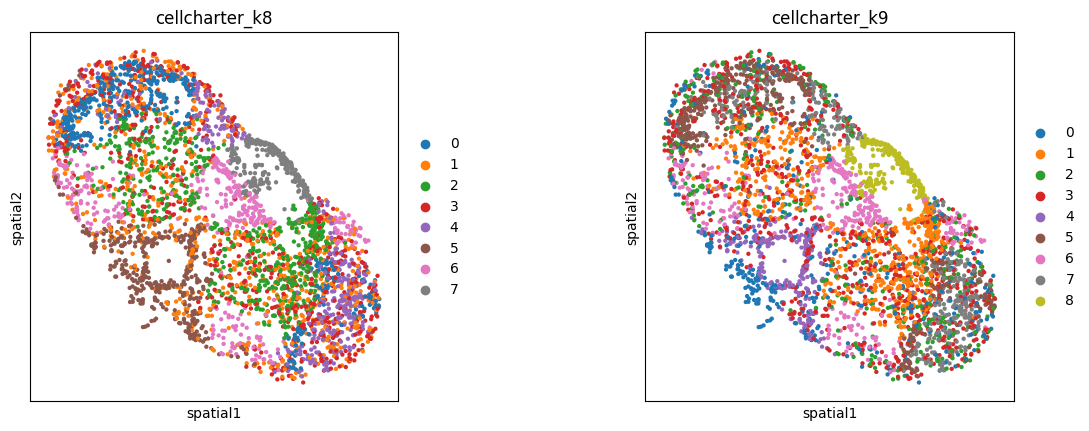

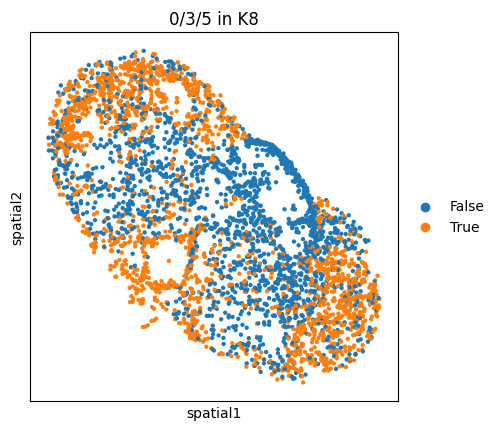

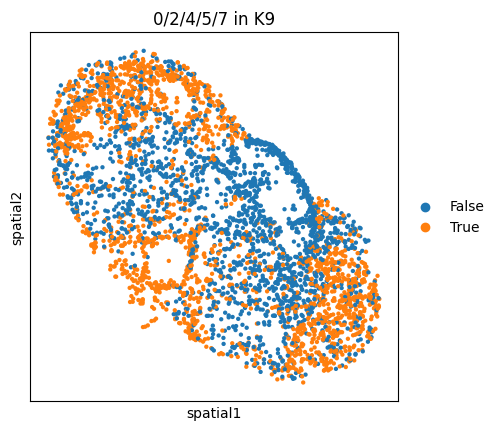

In [59]:
s1 = adata[adata.obs['sample'] == adata.obs['sample'].unique()[0]].copy()
sc.pl.spatial(s1, basis='spatial', color=['cellcharter_k8','cellcharter_k9'], spot_size=50)
adata.obs["temp"] = adata.obs["cellcharter_k8"].isin(["0","3","5"])
sc.pl.spatial(s1, basis='spatial', color=['temp'], spot_size=50, title="0/3/5 in K8")
adata.obs["temp"] = adata.obs["cellcharter_k9"].isin(["2","0","4","7","5"])
sc.pl.spatial(s1, basis='spatial', color=['temp'], spot_size=50, title="0/2/4/5/7 in K9")

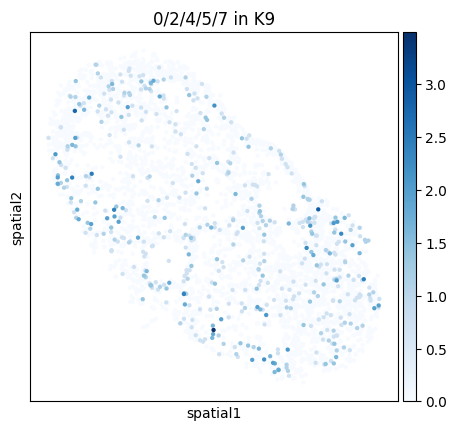

In [ ]:
sc.pl.spatial(s1, basis='spatial', color=['Fos'], spot_size=50, title="0/2/4/5/7 in K9", layer="logcounts", cmap="Blues")

In [104]:
cluster_sankey(adata.obs["celltype"],adata.obs["cellcharter_k8"])

# Look at a neighborhoods

In [ ]:
gc.collect()
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
adata

### Spatially variable genes

In [ ]:
del adata.uns['moranI'], adata.uns["gearyC"]
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

adata.uns["moranI"].head(50).index
adata.uns["gearyC"].head(10).index

In [ ]:
moranI = adata.uns["moranI"]
moranI = moranI[moranI.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)]

gearyC = adata.uns["moranI"]
gearyC = gearyC[gearyC.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)]

# adata.uns["gearyC"].loc[["Chat", "Phox2b"]]
moranI.reset_index()[moranI.index.isin(["Chat", "Phox2b"])]

In [ ]:
top_n = 50
min_cells = 300

moranI = adata.uns["moranI"]
moranI = moranI[moranI.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)]
sc.pl.spatial(adata[adata.obs['sample'] == adata.obs['sample'].unique()[0]],
              color=moranI.index[:top_n],
              spot_size=50, layer="logcounts", cmap="Blues", ncols=10)


gearyC = adata.uns["moranI"]
gearyC = gearyC[gearyC.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)]
sc.pl.spatial(adata[adata.obs['sample'] == adata.obs['sample'].unique()[0]],
              color=gearyC.index[:top_n],
              spot_size=50, layer="logcounts", cmap="Blues", ncols=10)

### Neighborhood Enrichment Matrix
What is close to what? 

In [ ]:
adjacencies = ["celltype", 'BANKSY_labels_scaled_gaussian_pc30_nc0.50_r0.40', "cellcharter_k8"]
run = False
if run is True:
    sq.gr.spatial_neighbors(adata, spatial_key='spatial')
    for cluster in adjacencies:
        sq.gr.nhood_enrichment(adata, cluster_key=cluster)

f = plt.figure(figsize=(10,15), layout='constrained')
sf = f.subfigures(1, 2, width_ratios=[3, 1])
axs1 = sf[0].subplots(3, 1)
axs2 = sf[1].subplots(3, 1)

for i,cluster in enumerate(adjacencies):
    sc.pl.spatial(adata, basis='spatial', color=cluster, spot_size=50, ax=axs1[i], show=False)
    sq.pl.nhood_enrichment(adata, cluster_key=cluster, ax=axs2[i], normalize=True, cmap="Blues")
f.suptitle("Neigborhood enrichment")

In [ ]:
# neighborhood composition
group = adjacencies[2]
celltype = "seurat_clusters"

f = plt.figure(figsize=(10, 10), layout="constrained")
axs = f.subplots(2, 2)
axs = axs.flatten()
plot_cluster_stackedbarplot(
    adata, group, celltype, pct=False, ax=axs[0]
)
plot_cluster_stackedbarplot(adata, group, celltype, pct=True, ax=axs[1])
plot_cluster_stackedbarplot(
    adata, celltype, group, pct=False, ax=axs[2]
)
plot_cluster_stackedbarplot(adata, celltype, group, pct=True, ax=axs[3])


crosstab = pd.crosstab(adata.obs[celltype], adata.obs[group]).astype(int)
f,axs = plt.subplots(1,2, figsize=(16, 8), layout="constrained")
sns.heatmap(crosstab.div(crosstab.sum(axis=1),axis=0),
            cmap="Reds", annot=crosstab, fmt='d', ax=axs[0])
axs[0].set_title("Normalized by row (per celltype)", size=12)

sns.heatmap(crosstab.div(crosstab.sum(axis=0),axis=1),
            cmap="Reds", annot=crosstab, fmt='d', ax=axs[1])
axs[1].set_title("normalized by column (per neighborhood)", size=12)
f.suptitle("Percent Celltypes by Neighorhood (count annotated)", size=18)


sc.pl.spatial(adata[adata.obs['sample'] == adata.obs['sample'].unique()[0]], basis='spatial', color=adjacencies[2], spot_size=50, title=f"{adata.obs['sample'].unique()[0]} ({adjacencies[2]})")

In [ ]:
tmp = adata[adata.obs["seurat_clusters"] == "12"]
sc.tl.rank_genes_groups(
    tmp,
    groupby=f"cellcharter_k8",
    use_raw=False,
    groups=["6","7"],
    layer="logcounts",
    method="wilcoxon",
)
sc.pl.rank_genes_groups(tmp)
sc.pl.spatial(adata[adata.obs['sample'] == adata.obs['sample'].unique()[0]], color=['Scg2','Hoxa5'], spot_size=50,
              layer="logcounts", cmap="Blues")

In [ ]:
adata.obs['banksy_plot'] = adata.obs[adjacencies[1]]
group = 'banksy_plot'
celltype = adjacencies[0]

f = plt.figure(figsize=(10, 10), layout="constrained")
axs = f.subplots(2, 2)
axs = axs.flatten()
plot_cluster_stackedbarplot(
    adata, group, celltype, pct=False, ax=axs[0]
)
plot_cluster_stackedbarplot(adata, group, celltype, pct=True, ax=axs[1])
plot_cluster_stackedbarplot(
    adata, celltype, group, pct=False, ax=axs[2]
)
plot_cluster_stackedbarplot(adata, celltype, group, pct=True, ax=axs[3])


crosstab = pd.crosstab(adata.obs[celltype], adata.obs[group]).astype(int)
f,axs = plt.subplots(1,2, figsize=(16, 8), layout="constrained")
sns.heatmap(crosstab.div(crosstab.sum(axis=1),axis=0),
            cmap="Reds", annot=crosstab, fmt='d', ax=axs[0])
axs[0].set_title("Normalized by row (per celltype)", size=12)

sns.heatmap(crosstab.div(crosstab.sum(axis=0),axis=1),
            cmap="Reds", annot=crosstab, fmt='d', ax=axs[1])
axs[1].set_title("normalized by column (per neighborhood)", size=12)
f.suptitle("Percent Celltypes by Neighorhood (count annotated)", size=18)

sc.pl.spatial(adata[adata.obs['sample'] == adata.obs['sample'].unique()[0]], basis='spatial', color='banksy_plot', spot_size=50, title=f"{adata.obs['sample'].unique()[0]} (banksy_plot)")

### Co-occurrence Plots
Probability of finding a cluster as you go a further distance from **one specific cluster of interest**.
* This has to be done on a per-sample basis.

In [ ]:
run = True
if run is True:
    warnings.filterwarnings("ignore")
    split_adatas = []
    for sample in adata.obs["sample"].unique():
        tmp = adata[adata.obs["sample"] == sample].copy()
        sq.gr.co_occurrence(tmp, spatial_key='SPATIAL', n_jobs=CORES, cluster_key="celltype",show_progress_bar=False)
        split_adatas.append(tmp)

for tmp in split_adatas:
    sq.pl.co_occurrence(tmp, cluster_key="celltype", clusters=tmp.obs["celltype"].unique())

In [ ]:
split_adatas[3].uns['celltype_co_occurrence']['interval']

In [ ]:
split_adatas[0].uns["celltype_co_occurrence"]['occ'].shape

In [ ]:
sq.pl.co_occurrence(split_adatas[0], cluster_key="celltype", clusters=tmp.obs["celltype"].unique())

# Requested plots 11/6

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")

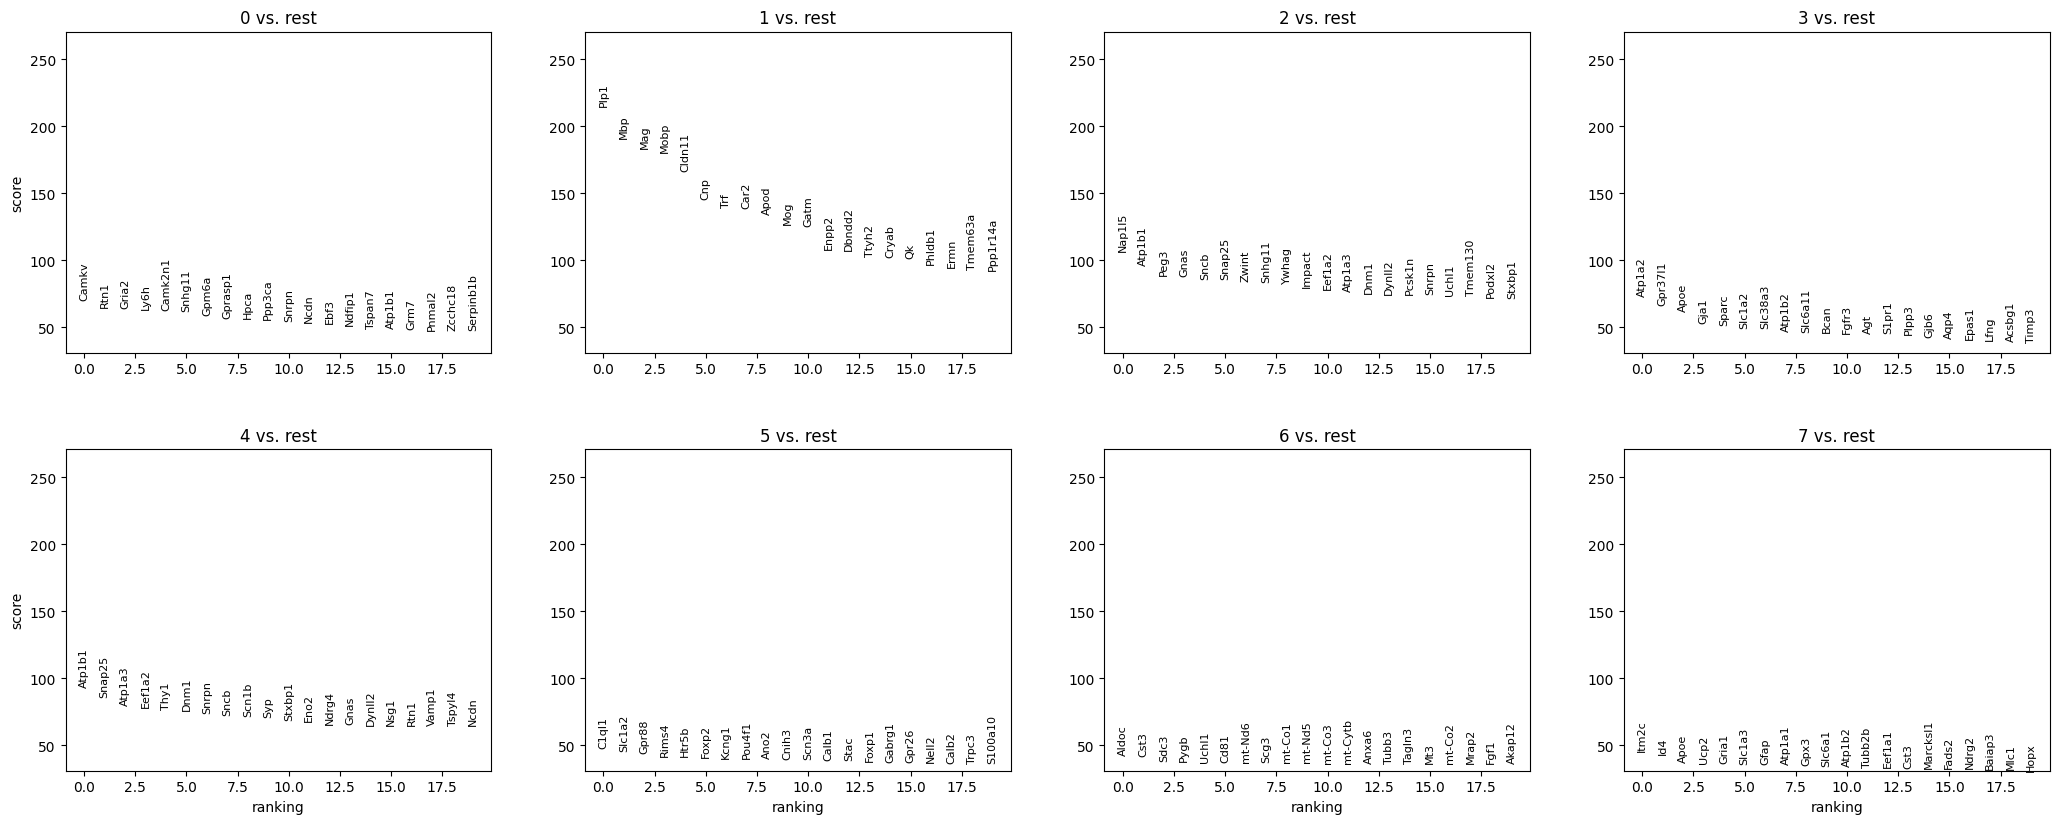

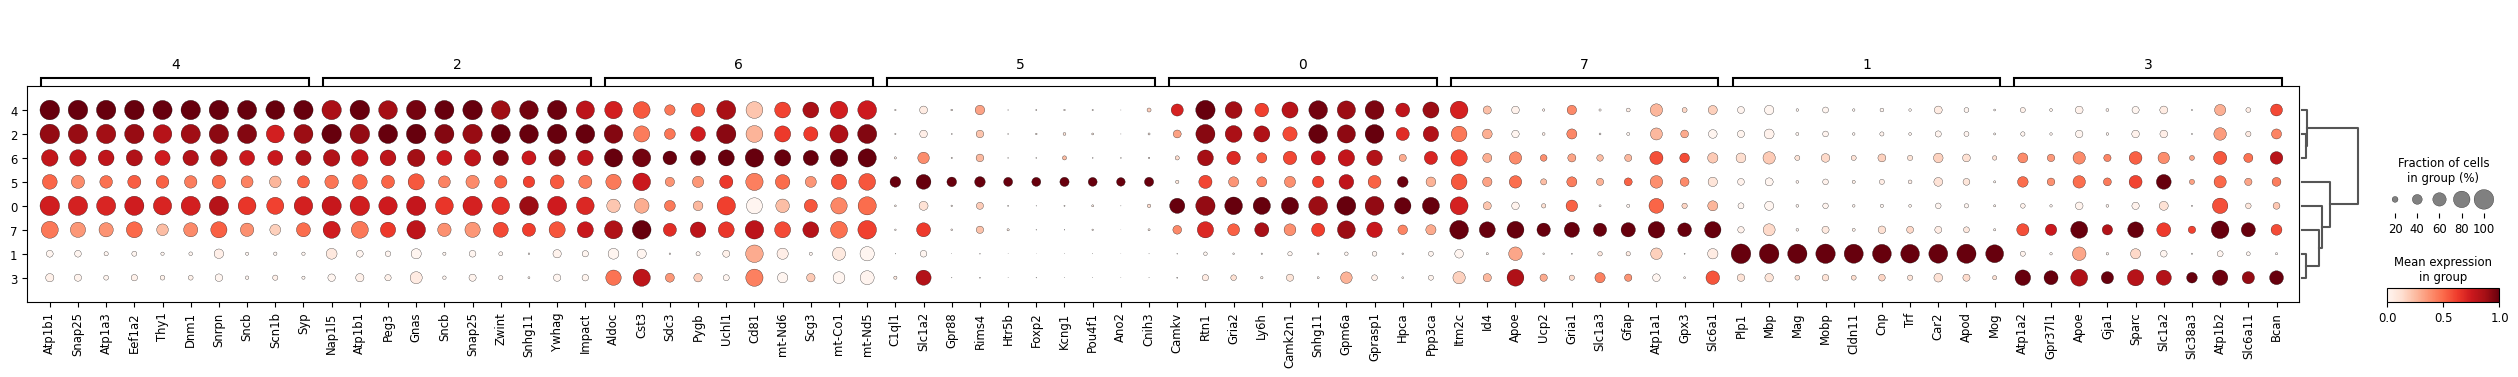

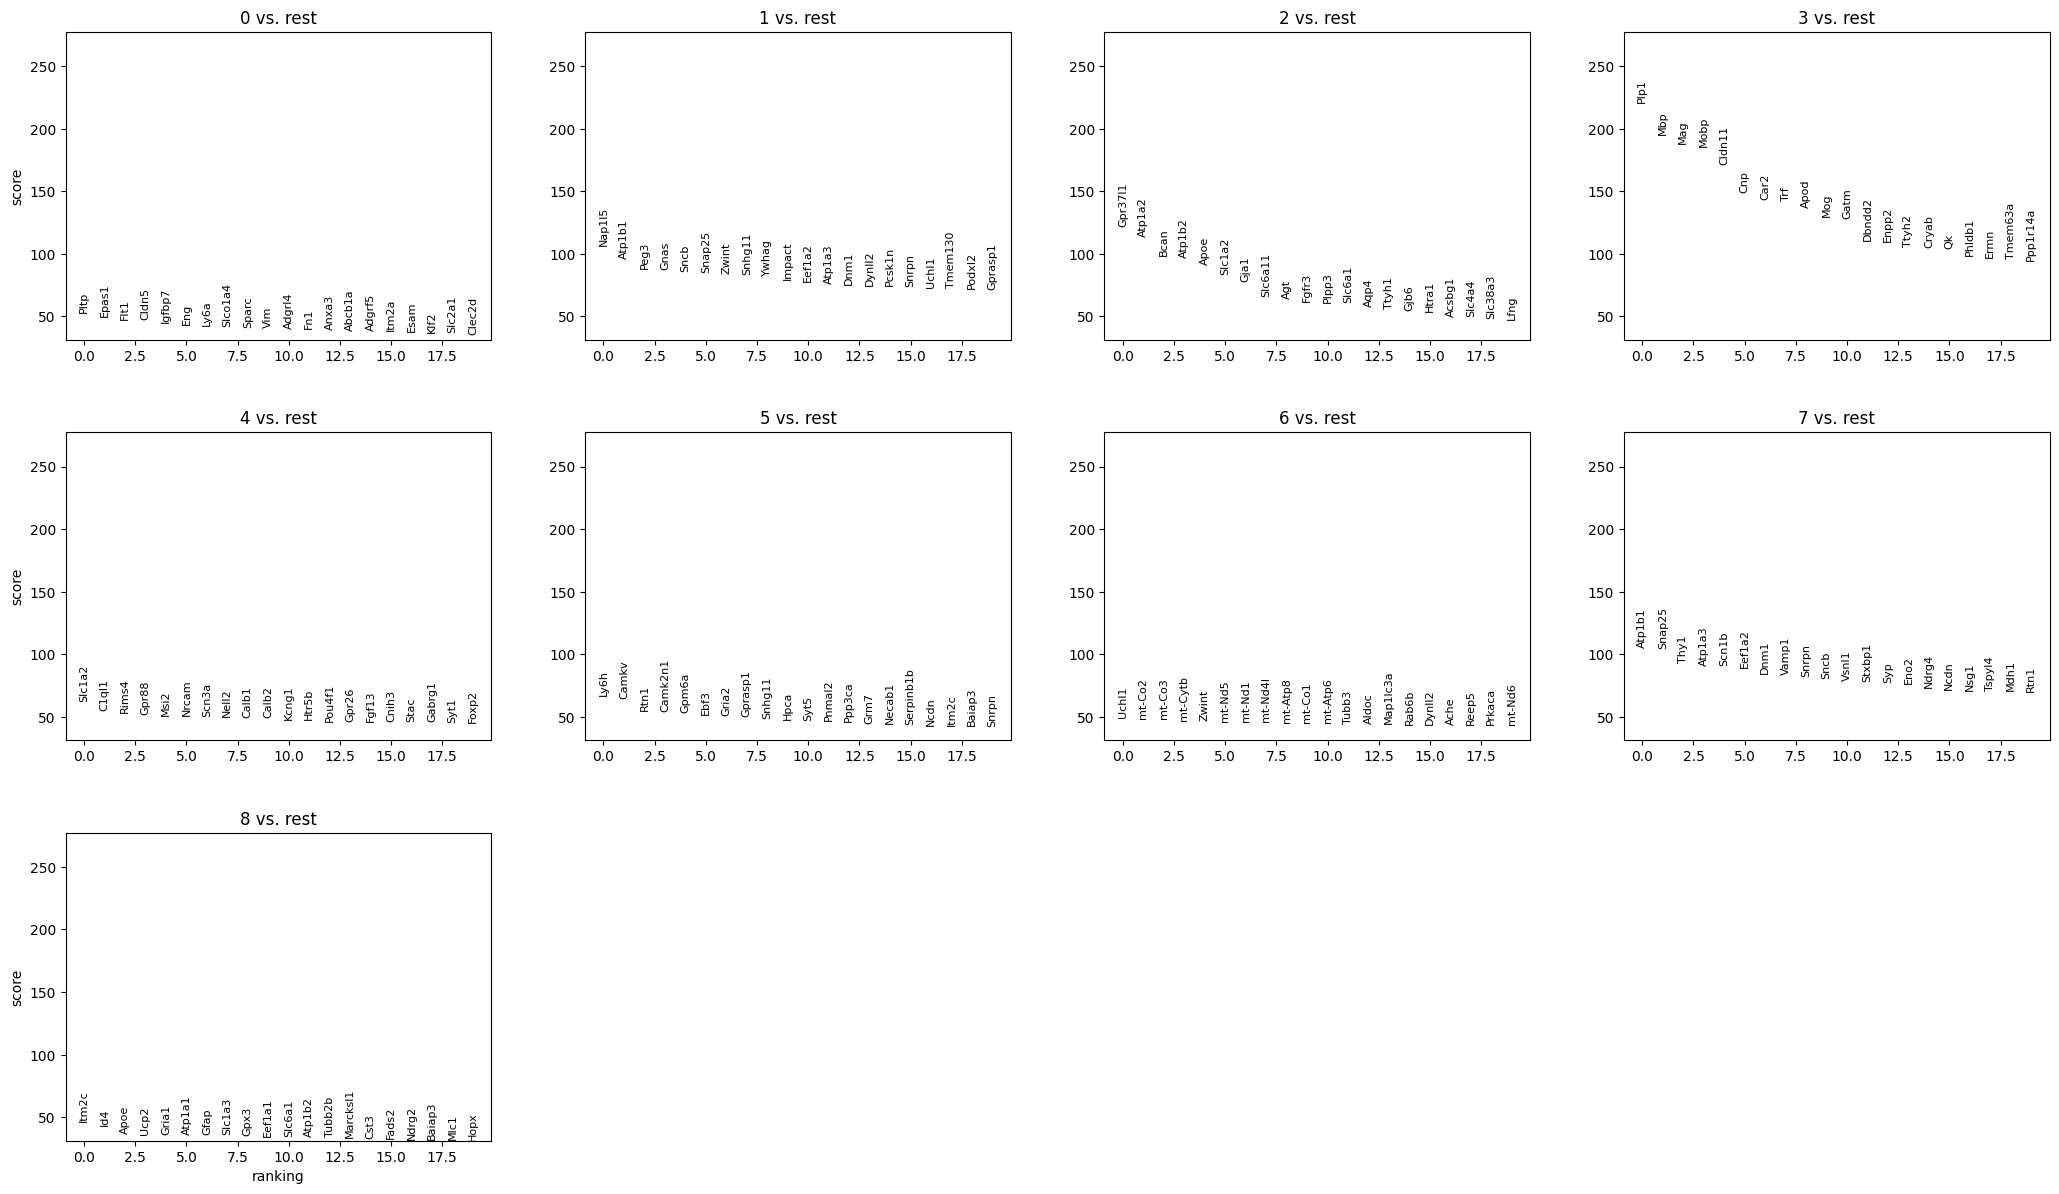

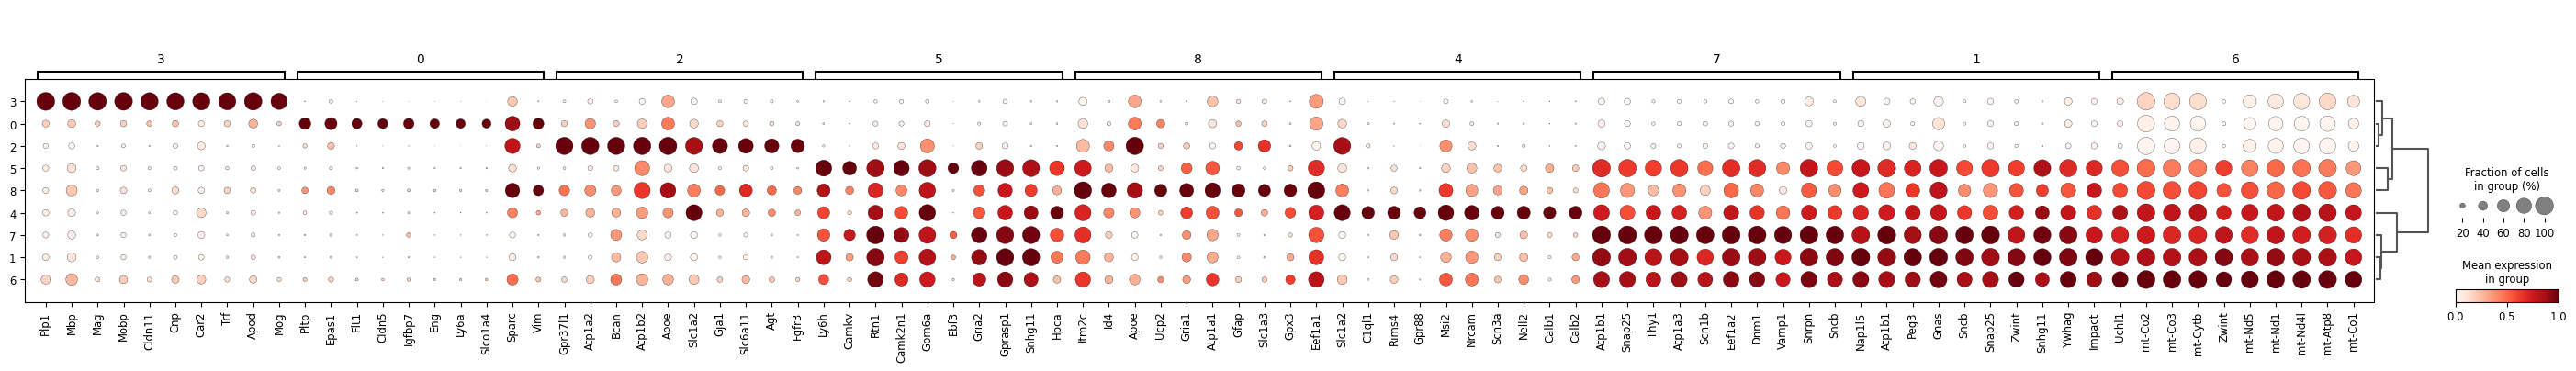

In [125]:
deg_key = "DEGs_cck8"
cluster = "cellcharter_k8"
run = False

if run is True:
    sc.tl.rank_genes_groups(adata, groupby=cluster, key_added=deg_key, layer="logcounts")

sc.pl.rank_genes_groups(adata, groupby=cluster, key=deg_key)
sc.pl.rank_genes_groups_dotplot(adata, groupby=cluster, key=deg_key, n_genes=10, standard_scale='var', layer="logcounts")

deg_key = "DEGs_cck9"
cluster = "cellcharter_k9"
run = False

if run is True:
    sc.tl.rank_genes_groups(adata, groupby=cluster, key_added=deg_key, layer="logcounts")

sc.pl.rank_genes_groups(adata, groupby=cluster, key=deg_key)
sc.pl.rank_genes_groups_dotplot(adata, groupby=cluster, key=deg_key, n_genes=10, standard_scale='var', layer="logcounts")

Index(['0', '1', '2', '3', '4', '5', '6', '7'], dtype='object')

3603


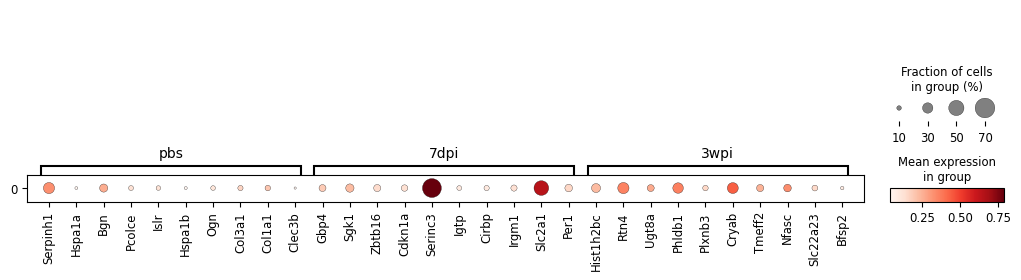

6174


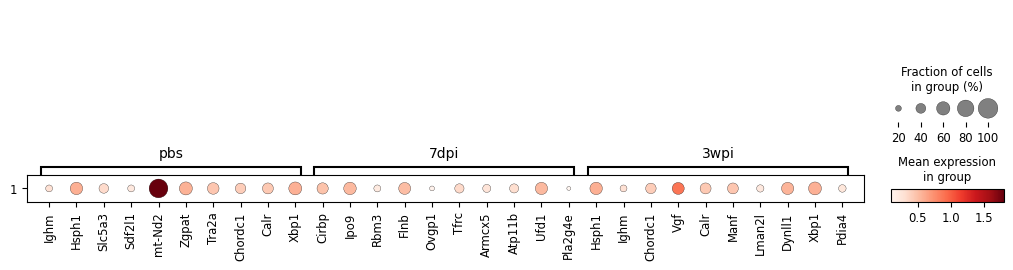

3243


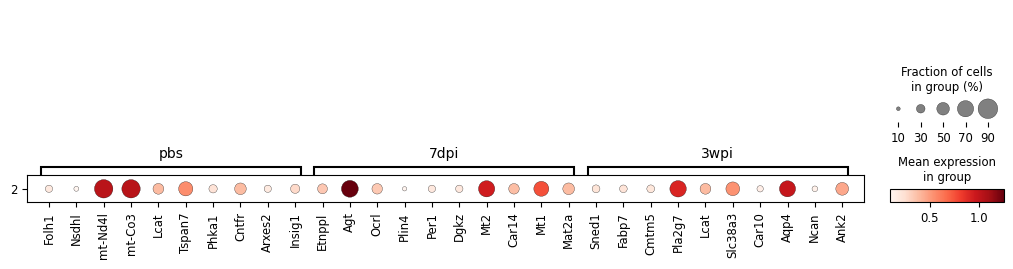

5936


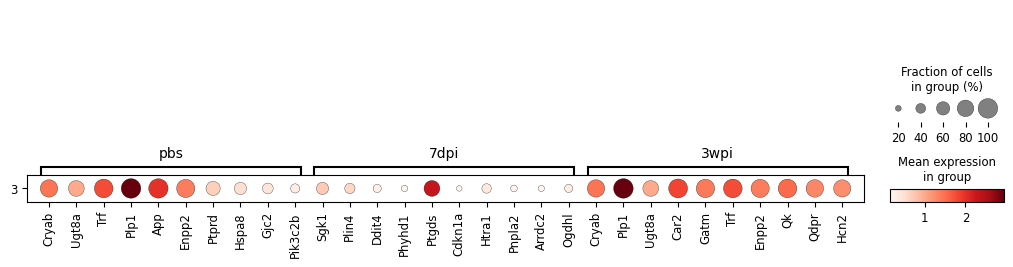

2580


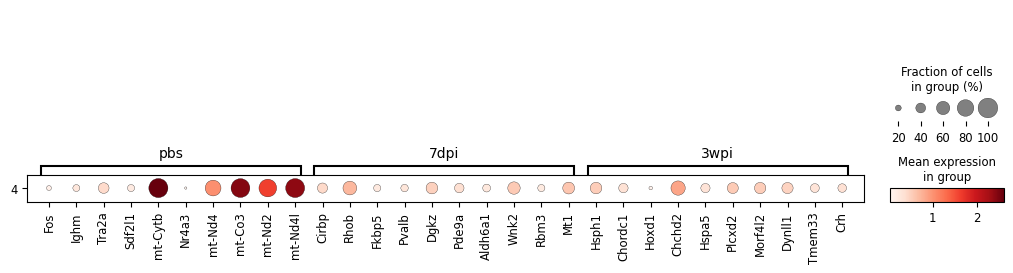

4848


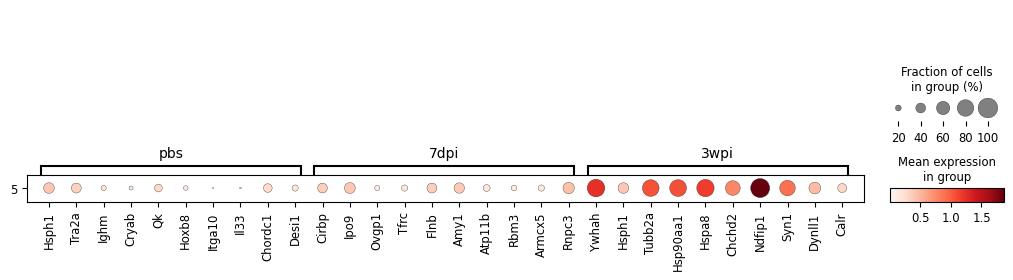

3584


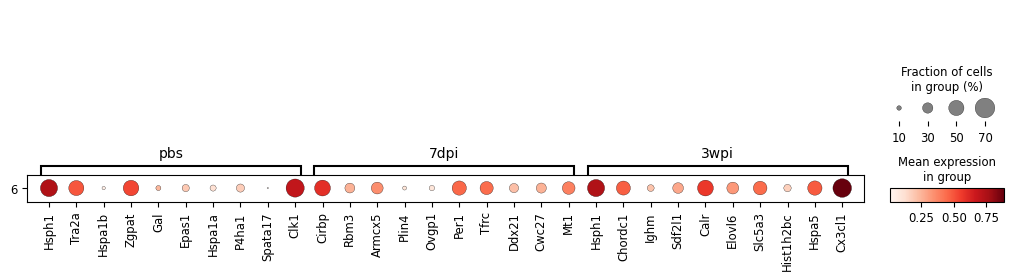

4400


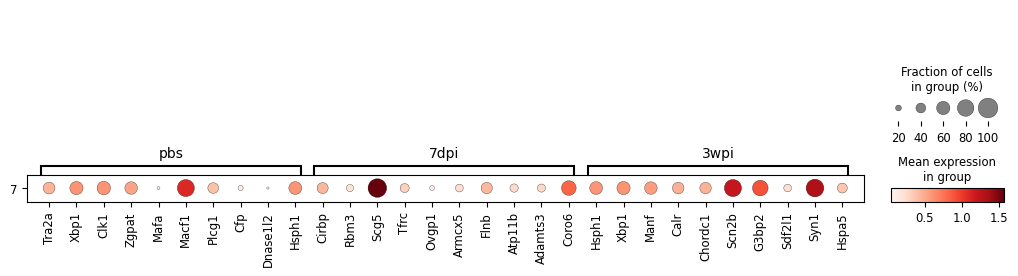

1976


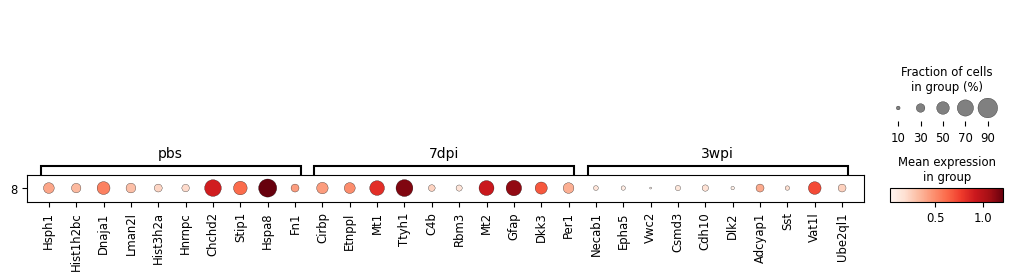

In [132]:
cluster = "cellcharter_k9"
compare = "timepoint"

for neighborhood in adata.obs[cluster].cat.categories:
    temp = adata[adata.obs[cluster] == neighborhood]
    print(temp.shape[0])
    sc.tl.rank_genes_groups(temp, groupby=compare, layer="logcounts")
    sc.pl.rank_genes_groups_dotplot(temp, groupby=cluster, n_genes=10, layer="logcounts")

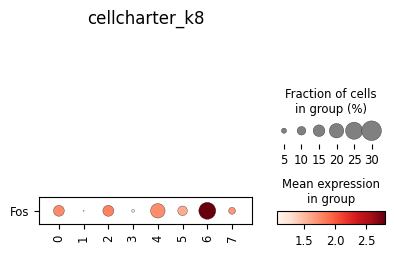

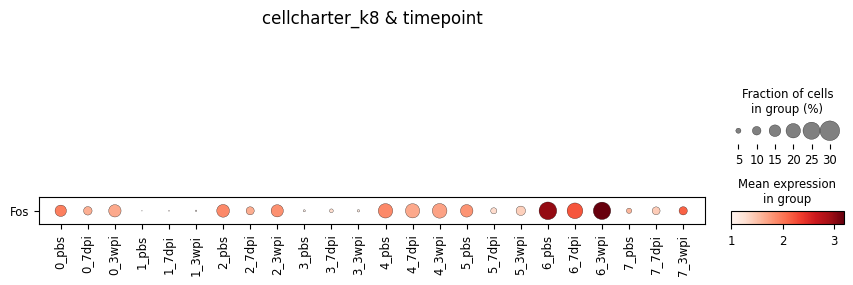

In [ ]:
sc.pl.dotplot(adata, var_names="Fos", groupby=["cellcharter_k8"], swap_axes=True, title="cellcharter_k8", mean_only_expressed=True)
sc.pl.dotplot(adata, var_names="Fos", groupby=["cellcharter_k8","timepoint"], swap_axes=True, title="cellcharter_k8 & timepoint", mean_only_expressed=True)

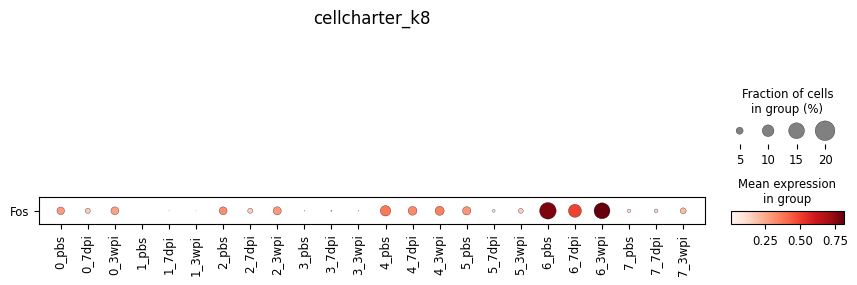

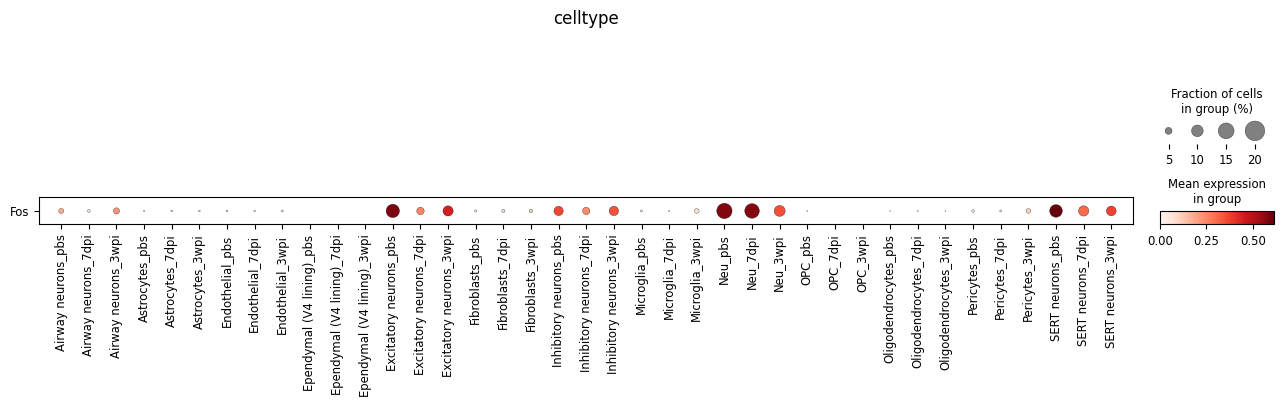

In [ ]:
sc.pl.dotplot(adata, var_names="Fos", groupby=["cellcharter_k8","timepoint"], swap_axes=True, title="cellcharter_k8", mean_only_expressed=True)
# sc.pl.dotplot(adata, var_names="Fos", groupby="cellcharter_k9", swap_axes=True, title="cellcharter_k9", expression_cutoff=1)
sc.pl.dotplot(adata, var_names="Fos", groupby=["celltype","timepoint"], swap_axes=True, title="celltype", expression_cutoff=1)